## Setup

In [ ]:
!pip install pygad


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
!wget https://raw.githubusercontent.com/NVlabs/sionna/refs/heads/main/src/sionna/phy/fec/ldpc/codes/5G_bg1.csv
!wget https://raw.githubusercontent.com/NVlabs/sionna/refs/heads/main/src/sionna/phy/fec/ldpc/codes/5G_bg2.csv

Will not apply HSTS. The HSTS database must be a regular and non-world-writable file.
ERROR: could not open HSTS store at '/headless/.wget-hsts'. HSTS will be disabled.
--2026-04-28 16:07:12--  https://raw.githubusercontent.com/NVlabs/sionna/refs/heads/main/src/sionna/phy/fec/ldpc/codes/5G_bg1.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9599 (9.4K) [text/plain]
Saving to: ‘5G_bg1.csv.1’

5G_bg1.csv.1        100%[===================>]   9.37K  --.-KB/s    in 0.009s  

2026-04-28 16:07:12 (1.01 MB/s) - ‘5G_bg1.csv.1’ saved [9599/9599]

Will not apply HSTS. The HSTS database must be a regular and non-world-writable file.
ERROR: could not open HSTS store at '/headless/.wget-hsts'. HSTS will be disabled.
--2026-04-28 16:07:12--  https://raw.githubusercont

## Read Base Graph

In [1]:
import numpy as np

def load_basegraph(i_ls: int, bg: str) -> np.ndarray:
    """Helper to load basegraph from csv files.

    ``i_ls`` is sub_index of the basegraph and fixed during lifting
    selection.
    """
    if i_ls > 7:
        raise ValueError("i_ls too large.")

    if i_ls < 0:
        raise ValueError("i_ls cannot be negative.")

    # csv files are taken from 38.212 and dimension is explicitly given
    if bg == "bg1":
        bm = np.zeros([46, 68]) - 1  # init matrix with -1 (None positions)
    elif bg == "bg2":
        bm = np.zeros([42, 52]) - 1  # init matrix with -1 (None positions)
    else:
        raise ValueError("Basegraph not supported.")

    # And load the basegraph from csv format in folder "codes"
    bg_csv = np.genfromtxt(f"5G_{bg}.csv", delimiter=";")

    # Reconstruct BG for given i_ls
    r_ind = 0
    for r in np.arange(2, bg_csv.shape[0]):
        # Check for next row index
        if not np.isnan(bg_csv[r, 0]):
            r_ind = int(bg_csv[r, 0])
        c_ind = int(bg_csv[r, 1])  # second column in csv is column index
        value = bg_csv[r, i_ls + 2]  # i_ls entries start at offset 2
        bm[r_ind, c_ind] = value

    return bm

Visualize base graph for inspection

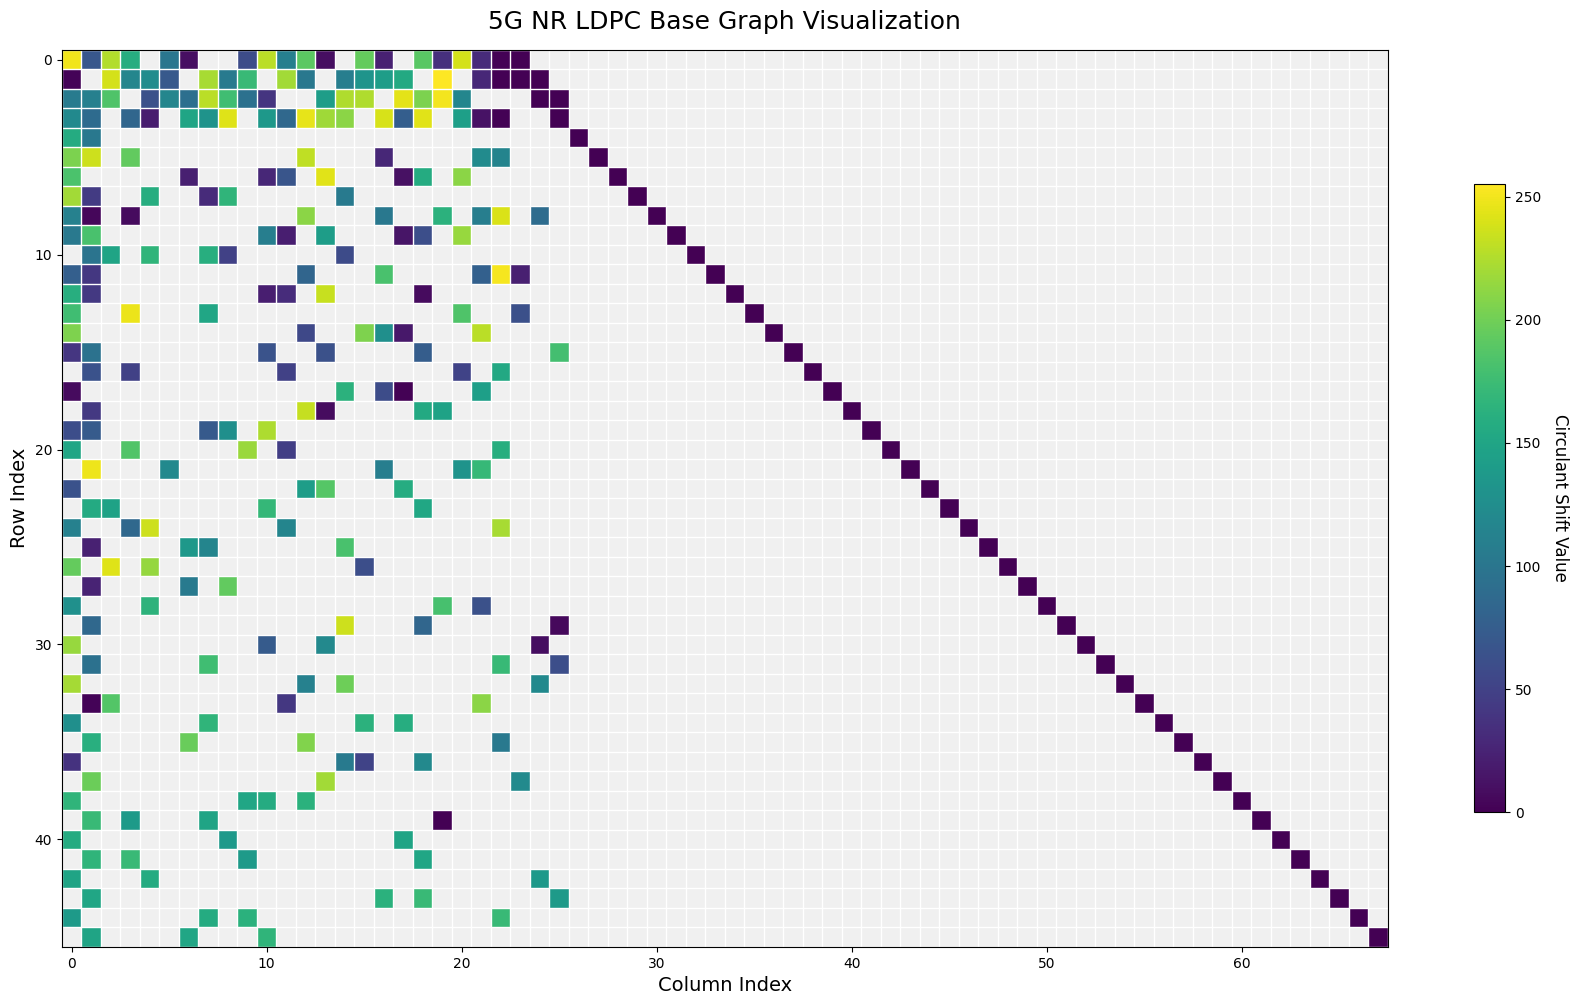

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Load the matrix ---
# (Assuming your load_basegraph function is already defined in the notebook)
# Let's use Base Graph 1, Lifting Set 0 as an example
bg_matrix = load_basegraph(i_ls=0, bg="bg1")

# --- 2. Mask the empty submatrices ---
# Mask the -1 values so they don't skew the color scale of the actual shift values
masked_bg = np.ma.masked_where(bg_matrix == -1, bg_matrix)

# --- 3. Set up the plot ---
fig, ax = plt.subplots(figsize=(18, 10))

# Define a colormap for the shift values.
# We explicitly set the "bad" (masked -1) values to a light gray background.
cmap = plt.cm.viridis.copy()
cmap.set_bad(color='#f0f0f0')

# Plot the matrix using imshow
# interpolation='none' ensures the blocks are crisp and not blurry
cax = ax.imshow(masked_bg, cmap=cmap, aspect='equal', interpolation='none')

# --- 4. Add gridlines for clarity ---
# Draw white gridlines between each cell to clearly separate the submatrices
ax.set_xticks(np.arange(-0.5, bg_matrix.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, bg_matrix.shape[0], 1), minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=1)
ax.tick_params(which='minor', size=0) # Hide minor tick marks

# --- 5. Labels and styling ---
plt.title("5G NR LDPC Base Graph Visualization", fontsize=18, pad=15)
plt.xlabel("Column Index", fontsize=14)
plt.ylabel("Row Index", fontsize=14)

# Add a colorbar to map the colors back to the numerical shift values
cbar = plt.colorbar(cax, shrink=0.7)
cbar.set_label("Circulant Shift Value", rotation=270, labelpad=20, fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
bg_matrix

array([[250.,  69., 226., ...,  -1.,  -1.,  -1.],
       [  2.,  -1., 239., ...,  -1.,  -1.,  -1.],
       [106., 111., 185., ...,  -1.,  -1.,  -1.],
       ...,
       [ -1., 151.,  -1., ...,   0.,  -1.,  -1.],
       [139.,  -1.,  -1., ...,  -1.,   0.,  -1.],
       [ -1., 149.,  -1., ...,  -1.,  -1.,   0.]], shape=(46, 68))

## Optimization

In [4]:
import pygad
import numpy as np

ModuleNotFoundError: No module named 'pygad'

In [5]:
# ==============================================================================
# 1. Base Graph (BG) Input Matrices
# ==============================================================================
# REPLACE THESE WITH YOUR ACTUAL MATRICES (List of lists or 2D Numpy arrays).
# The matrices should contain your shift values, with -1 indicating an empty submatrix.

# Dummy generator just to make this script runnable out-of-the-box.
def generate_dummy_matrix(rows, cols):
    matrix = np.full((rows, cols), -1)
    for r in range(rows):
        num_cpms = np.random.randint(3, 11)
        active_cols = np.random.choice(range(cols), size=num_cpms, replace=False)
        for c in active_cols:
            matrix[r][c] = np.random.randint(0, 100) # Random shift value
    return matrix.tolist()

BG1_MATRIX = load_basegraph(i_ls=1, bg='bg1')
BG2_MATRIX = load_basegraph(i_ls=1, bg='bg2')

# Dummy optimized schedules (representing the permutations of rows 4+)
# Replace these with the actual output arrays from the GA optimization script!
BG1_SCHEDULE = list(range(4, 46)) # Replace with optimized list of 42 elements
np.random.shuffle(BG1_SCHEDULE)

BG2_SCHEDULE = list(range(4, 42)) # Replace with optimized list of 38 elements
np.random.shuffle(BG2_SCHEDULE)

In [6]:
# ==============================================================================
# 2. Base Graph Configurations & Parser
# ==============================================================================
BG_CONFIGS = {
    "BG1": {
        "matrix": BG1_MATRIX,
        "schedule": BG1_SCHEDULE,
        "num_rows": 46,
        "kb": 22
    },
    "BG2": {
        "matrix": BG2_MATRIX,
        "schedule": BG2_SCHEDULE,
        "num_rows": 42,
        "kb": 10
    }
}


def parse_bg_matrix(matrix, num_rows, kb):
    """
    Converts a 2D base graph matrix into a dictionary of input dependencies.
    Filters out OUTPUT columns which do not consume Circular Shifter cycles.
    """
    bg_dict = {}
    for r in range(num_rows):
        input_cols = []
        for c, val in enumerate(matrix[r]):
            if val != -1:
                if r < 4:
                    # Rows 0-3 CALCULATE Core Parity.
                    # Main CS only shifts Information bits (c < kb).
                    if c < kb:
                        input_cols.append(c)
                else:
                    # Rows 4+ CALCULATE Additional Parity.
                    # Main CS shifts Info bits AND Core Parity bits (c < kb + 4).
                    if c < kb + 4:
                        input_cols.append(c)
        bg_dict[r] = input_cols
    return bg_dict

In [ ]:
# ==============================================================================
# 3. Strict Baseline Calculation (Section 4.1)
# ==============================================================================
def calculate_strict_baseline(bg_dict, start_row, num_rows):
    """
    Calculates the baseline from Section 4.1:
    Sequential processing with NO Core Parity hiding. Every unique column
    (Information or CP) costs 1 full cycle.
    (If using real 5G NR matrices, this will output 180 for BG1 and 94 for BG2).
    """
    # Cycles required to process the first 4 rows (Core Parity generation)
    first_4_cols = set()
    for r in range(4):
        first_4_cols.update(bg_dict.get(r, []))
    total_cycles = len(first_4_cols)

    # Process remaining rows in chunks of 4 sequentially
    row_indices = list(range(start_row, num_rows))
    for i in range(0, len(row_indices), 4):
        chunk = row_indices[i:i+4]
        chunk_cols = set()

        for r in chunk:
            # Union of ALL columns (both Info and CP) since no hiding occurs
            chunk_cols.update(bg_dict.get(r, []))

        total_cycles += len(chunk_cols)

    return total_cycles

In [ ]:
# ==============================================================================
# 4. Hardware-Accurate Fitness Function Factory (Section 4.2)
# ==============================================================================
def create_fitness_func(bg_dict, kb):
    """
    Simulates cycle count WITH the "Repositioning" (CP hiding) optimization.
    """
    first_4_info = set()
    for r in range(4):
        first_4_info.update(bg_dict.get(r, []))
    fixed_cycles = len(first_4_info)

    def fitness_func(ga_instance, solution, solution_idx):
        total_cycles = fixed_cycles

        for i in range(0, len(solution), 4):
            chunk = solution[i:i+4]
            shifter_info_reqs = []
            shifter_cp_reqs = []

            for row_idx in chunk:
                cols = bg_dict.get(row_idx, [])
                shifter_info_reqs.append([c for c in cols if c < kb])
                shifter_cp_reqs.append([c for c in cols if kb <= c < kb + 4])

            info_bus_broadcasts = set()
            for reqs in shifter_info_reqs:
                info_bus_broadcasts.update(reqs)

            base_cycles_for_chunk = len(info_bus_broadcasts)
            remaining_cp_reqs = [list(reqs) for reqs in shifter_cp_reqs]

            # CP Hiding simulation
            for broadcasted_info_col in info_bus_broadcasts:
                idle_shifters = [
                    shifter_idx for shifter_idx in range(len(chunk))
                    if broadcasted_info_col not in shifter_info_reqs[shifter_idx]
                ]
                if not idle_shifters:
                    continue

                needed_cps_by_idle = {}
                for shifter_idx in idle_shifters:
                    for cp in remaining_cp_reqs[shifter_idx]:
                        needed_cps_by_idle[cp] = needed_cps_by_idle.get(cp, 0) + 1

                if needed_cps_by_idle:
                    broadcasted_cp_col = max(needed_cps_by_idle, key=needed_cps_by_idle.get)
                    for shifter_idx in idle_shifters:
                        if broadcasted_cp_col in remaining_cp_reqs[shifter_idx]:
                            remaining_cp_reqs[shifter_idx].remove(broadcasted_cp_col)

            unhidden_cp_broadcasts = set()
            for reqs in remaining_cp_reqs:
                unhidden_cp_broadcasts.update(reqs)

            total_cycles += base_cycles_for_chunk + len(unhidden_cp_broadcasts)

        return 1.0 / total_cycles

    return fitness_func

In [ ]:
# ==============================================================================
# 5. Optimization Pipeline
# ==============================================================================
def optimize_base_graph(bg_name, config):
    print(f"\n{'='*50}")
    print(f"Optimizing Schedule for {bg_name}")
    print(f"{'='*50}")

    bg_dict = parse_bg_matrix(config["matrix"], config["num_rows"], config["kb"])
    row_indices = list(range(config["start_row"], config["num_rows"]))

    strict_baseline_cycles = calculate_strict_baseline(bg_dict, config["start_row"], config["num_rows"])

    fitness = create_fitness_func(bg_dict, config["kb"])
    sequential_hiding_cycles = int(1.0 / fitness(None, row_indices, 0))

    print(f"1. Strict Baseline (Sec 4.1, no CP hiding): {strict_baseline_cycles} cycles")
    print(f"2. Sequential + CP Hiding (Sec 4.2 logic):  {sequential_hiding_cycles} cycles")

    ga_instance = pygad.GA(
        num_generations=2000,
        num_parents_mating=25,
        fitness_func=fitness,
        sol_per_pop=300,
        num_genes=len(row_indices),
        gene_type=int,
        gene_space=row_indices,
        allow_duplicate_genes=False,
        mutation_type="swap",
        mutation_probability=0.25,
        crossover_type="single_point",
        parent_selection_type="sss",
        keep_elitism=15
    )

    print("\nRunning Genetic Algorithm...")
    ga_instance.run()

    solution, solution_fitness, solution_idx = ga_instance.best_solution()
    optimized_cycles = int(1.0 / solution_fitness)

    print(f"\n--- {bg_name} Final Results ---")
    print(f"3. GA Optimized + CP Hiding:       {optimized_cycles} cycles")
    print("-" * 40)
    print(f"Total Cycle Reduction:             {strict_baseline_cycles - optimized_cycles} cycles")
    print(f"Improvement vs Strict Baseline:    {((strict_baseline_cycles - optimized_cycles) / strict_baseline_cycles) * 100:.2f}%")

    print(f"\nOptimal Row Schedule for {bg_name} (Chunks of 4):")
    schedule_list = solution.tolist()
    for i in range(0, len(schedule_list), 4):
        chunk = schedule_list[i:i+4]
        print(f"  Cycle Block {i//4 + 1:02d}: Process Rows {chunk}")

    return schedule_list

In [ ]:
final_schedules = {}
for bg_name, config in BG_CONFIGS.items():
    final_schedules[bg_name] = optimize_base_graph(bg_name, config)

print("\n\nAll optimizations complete. The generated schedules can now be stored in the encoder's ROM.")


Optimizing Schedule for BG1
1. Strict Baseline (Sec 4.1, no CP hiding): 179 cycles
2. Sequential + CP Hiding (Sec 4.2 logic):  161 cycles

Running Genetic Algorithm...

--- BG1 Final Results ---
3. GA Optimized + CP Hiding:       112 cycles
----------------------------------------
Total Cycle Reduction:             67 cycles
Improvement vs Strict Baseline:    37.43%

Optimal Row Schedule for BG1 (Chunks of 4):
  Cycle Block 01: Process Rows [10, 7, 33, 28]
  Cycle Block 02: Process Rows [9, 30, 6, 12]
  Cycle Block 03: Process Rows [24, 4, 16, 40]
  Cycle Block 04: Process Rows [34, 14, 11, 17]
  Cycle Block 05: Process Rows [42, 26, 36, 32]
  Cycle Block 06: Process Rows [13, 20, 21, 44]
  Cycle Block 07: Process Rows [29, 37, 23, 43]
  Cycle Block 08: Process Rows [18, 15, 38, 22]
  Cycle Block 09: Process Rows [25, 19, 27, 31]
  Cycle Block 10: Process Rows [39, 8, 41, 5]
  Cycle Block 11: Process Rows [45, 35]

Optimizing Schedule for BG2
1. Strict Baseline (Sec 4.1, no CP hiding)

In [ ]:
def verify_cycle_counts(bg_name, config):
    print(f"\n{'='*45}")
    print(f"Cycle Breakdown for {bg_name}")
    print(f"{'='*45}")

    matrix = config["matrix"]
    num_rows = config["num_rows"]
    kb = config["kb"]
    start_row = config["start_row"]

    # 1. Parse matrix exactly as the hardware multiplexers do
    bg_dict = {}
    for r in range(num_rows):
        cols = []
        for c, val in enumerate(matrix[r]):
            if val != -1:
                if r < 4 and c < kb:
                    cols.append(c)
                elif r >= 4 and c < kb + 4:
                    cols.append(c)
        bg_dict[r] = cols

    # 2. Count Cycles for Rows 0-3 (Core Parity Calculation)
    first_4_cols = set()
    for r in range(4):
        first_4_cols.update(bg_dict[r])

    cycles_0_to_3 = len(first_4_cols)
    total_cycles = cycles_0_to_3
    print(f"Rows 00-03 (Core Parity Calc) : {cycles_0_to_3:02d} cycles")
    print("-" * 45)

    # 3. Count Cycles for remaining chunks of 4 (Additional Parity)
    chunk_idx = 1
    for i in range(start_row, num_rows, 4):
        chunk = list(range(i, min(i+4, num_rows)))
        chunk_cols = set()

        for r in chunk:
            chunk_cols.update(bg_dict[r])

        chunk_cycles = len(chunk_cols)
        total_cycles += chunk_cycles

        # Formatting the row range string for clean output
        row_str = f"{chunk[0]:02d}-{chunk[-1]:02d}"
        print(f"Chunk {chunk_idx:02d} (Rows {row_str})          : {chunk_cycles:02d} cycles")
        chunk_idx += 1

    print("-" * 45)
    print(f"Total Strict Baseline Cycles  : {total_cycles}")
    return total_cycles

for bg_name, config in BG_CONFIGS.items():
    verify_cycle_counts(bg_name, config)


Cycle Breakdown for BG1
Rows 00-03 (Core Parity Calc) : 22 cycles
---------------------------------------------
Chunk 01 (Rows 04-07)          : 18 cycles
Chunk 02 (Rows 08-11)          : 21 cycles
Chunk 03 (Rows 12-15)          : 16 cycles
Chunk 04 (Rows 16-19)          : 17 cycles
Chunk 05 (Rows 20-23)          : 16 cycles
Chunk 06 (Rows 24-27)          : 12 cycles
Chunk 07 (Rows 28-31)          : 13 cycles
Chunk 08 (Rows 32-35)          : 13 cycles
Chunk 09 (Rows 36-39)          : 13 cycles
Chunk 10 (Rows 40-43)          : 11 cycles
Chunk 11 (Rows 44-45)          : 07 cycles
---------------------------------------------
Total Strict Baseline Cycles  : 179

Cycle Breakdown for BG2
Rows 00-03 (Core Parity Calc) : 10 cycles
---------------------------------------------
Chunk 01 (Rows 04-07)          : 07 cycles
Chunk 02 (Rows 08-11)          : 10 cycles
Chunk 03 (Rows 12-15)          : 08 cycles
Chunk 04 (Rows 16-19)          : 09 cycles
Chunk 05 (Rows 20-23)          : 09 cycles
Chun

Save optimized schedules

In [ ]:
def save_schedules_to_files(schedules):
    """
    Saves the final optimized schedules into standard text files.
    Includes both a human-readable breakdown and a raw hardware array format.
    """
    print(f"\n{'='*50}")
    print("Exporting Schedules to Files")
    print(f"{'='*50}")

    for bg_name, schedule in schedules.items():
        filename = f"{bg_name}_optimized_schedule.txt"

        with open(filename, 'w') as f:
            f.write(f"// ==================================================\n")
            f.write(f"// Optimized Row Processing Schedule for {bg_name}\n")
            f.write(f"// Note: Rows 0-3 are processed first (fixed)\n")
            f.write(f"// ==================================================\n\n")

            f.write("--- Cycle-by-Cycle Breakdown (Chunks of 4) ---\n")
            for i in range(0, len(schedule), 4):
                chunk = schedule[i:i+4]
                # Format to 2 digits for cleaner reading (e.g., '05', '42')
                chunk_str = ", ".join(f"{r:02d}" for r in chunk)
                f.write(f"Cycle Block {i//4 + 1:02d}: {chunk_str}\n")

            f.write("\n\n--- Hardware Initialization Arrays (Copy & Paste) ---\n")
            f.write(f"// Python Array:\n")
            f.write(f"{bg_name}_SCHEDULE = {schedule}\n\n")

            f.write(f"// C / C++ Array:\n")
            f.write(f"const int {bg_name}_SCHEDULE[{len(schedule)}] = {{{', '.join(map(str, schedule))}}};\n\n")

            f.write(f"// SystemVerilog / Verilog Memory Initialization (Hex or Decimal):\n")
            for idx, val in enumerate(schedule):
                f.write(f"assign {bg_name}_rom[{idx}] = 6'd{val};\n")

        print(f"SUCCESS: Saved {bg_name} schedule to '{filename}'")

In [ ]:
save_schedules_to_files(final_schedules)


Exporting Schedules to Files
SUCCESS: Saved BG1 schedule to 'BG1_optimized_schedule.txt'
SUCCESS: Saved BG2 schedule to 'BG2_optimized_schedule.txt'


## CSR Transform

In [7]:
BG1_SCHEDULE = [10, 7, 33, 28, 9, 30, 6, 12, 24, 4, 16, 40, 34, 14, 11, 17, 42, 26, 36, 32, 13, 20, 21, 44, 29, 37, 23, 43, 18, 15, 38, 22, 25, 19, 27, 31, 39, 8, 41, 5, 45, 35]
BG2_SCHEDULE = [13, 19, 21, 31, 17, 28, 32, 41, 12, 25, 9, 23, 24, 16, 8, 22, 39, 36, 33, 37, 30, 38, 7, 26, 20, 29, 4, 15, 6, 18, 11, 34, 5, 14, 27, 10, 35, 40]

In [8]:
BG_CONFIGS["BG1"]["schedule"] = BG1_SCHEDULE
BG_CONFIGS["BG2"]["schedule"] = BG2_SCHEDULE

In [9]:
# ==============================================================================
# 1. Chronological CSR Simulation
# ==============================================================================

def generate_chronological_csr(config):
    """
    Simulates the hardware execution cycle-by-cycle to ensure the CSR arrays
    interleave the CP bits and Info bits in the exact order they are fetched.
    Also generates a 1-bit CP flag for each value.
    """
    matrix = config["matrix"]
    schedule = config["schedule"]
    kb = config["kb"]
    
    # ordered_cols[row_index] will store the columns in chronological fetch order
    ordered_cols = {r: [] for r in range(len(matrix))}
    
    # 1. Fixed Core Parity computation rows (Rows 0-3)
    # These only process Information bits in strictly ascending order
    for r in range(4):
        cols = [c for c, val in enumerate(matrix[r]) if val != -1 and c < kb]
        ordered_cols[r] = sorted(cols)
        
    # 2. Optimized schedule rows (Rows 4+, processed in chunks of 4)
    for i in range(0, len(schedule), 4):
        chunk = schedule[i:i+4]
        
        info_reqs = []
        cp_reqs = []
        for r in chunk:
            cols = [c for c, val in enumerate(matrix[r]) if val != -1]
            info_reqs.append([c for c in cols if c < kb])
            cp_reqs.append([c for c in cols if kb <= c < kb + 4])
            
        info_union = sorted(list(set(c for req in info_reqs for c in req)))
        remaining_cp = [list(req) for req in cp_reqs]
        
        # Simulate Cycle-by-Cycle Info Broadcasting
        for info_col in info_union:
            idle_shifters = []
            
            for idx, r in enumerate(chunk):
                if info_col in info_reqs[idx]:
                    ordered_cols[r].append(info_col) # Shifter is busy, consumes Info bit
                else:
                    idle_shifters.append(idx)        # Shifter is idle
                    
            # Sneak CP bits into idle shifters
            if idle_shifters:
                cp_counts = {}
                for idx in idle_shifters:
                    for cp in remaining_cp[idx]:
                        cp_counts[cp] = cp_counts.get(cp, 0) + 1
                
                if cp_counts:
                    # Tie-breaker: most needed CP, then lowest index to be deterministic
                    best_cp = max(cp_counts.keys(), key=lambda k: (cp_counts[k], -k))
                    
                    for idx in idle_shifters:
                        if best_cp in remaining_cp[idx]:
                            ordered_cols[chunk[idx]].append(best_cp) # Idle shifter consumes CP bit
                            remaining_cp[idx].remove(best_cp)
                            
        # Simulate cycles for any remaining CP bits that couldn't be hidden
        cp_union = sorted(list(set(c for req in remaining_cp for c in req)))
        for cp_col in cp_union:
            for idx, r in enumerate(chunk):
                if cp_col in remaining_cp[idx]:
                    ordered_cols[r].append(cp_col)
                    remaining_cp[idx].remove(cp_col)
                    
    # 3. Build the final CSR arrays
    values = []
    col_indices = []
    cp_flags = []
    row_ptr = [0]
    
    # We must append them in the order the hardware iterates through the rows
    restructured_rows = list(range(4)) + schedule
    
    for r in restructured_rows:
        for col in ordered_cols[r]:
            val = int(matrix[r][col])
            values.append(val)
            col_indices.append(int(col))
            # 1-bit flag: 1 if it's a Core Parity bit, 0 if it's an Information bit
            cp_flags.append(1 if (kb <= col < kb + 4) else 0)
            
        row_ptr.append(len(values))
        
    return values, col_indices, row_ptr, cp_flags

In [11]:
# ==============================================================================
# 3. Main Execution & .mem Export
# ==============================================================================
def generate_mem_files():
    print(f"\n{'='*60}")
    print(f"Generating Hexadecimal .mem Files (Chronological Order)")
    print(f"{'='*60}")
    
    # 1. Generate Chronological CSR for BG1
    val1, col1, ptr1, flag1 = generate_chronological_csr(BG_CONFIGS["BG1"])
    
    # 2. Generate Chronological CSR for BG2
    val2, col2, ptr2, flag2 = generate_chronological_csr(BG_CONFIGS["BG2"])
    
    # 3. Combine Value Data (BG1 followed by BG2)
    val_combined = val1 + val2
    col_combined = col1 + col2
    flag_combined = flag1 + flag2
    
    # Offset BG2's row pointers
    ptr2_offset = [p + len(val1) for p in ptr2]
    
    # 4. Pack Row Pointers SEPARATELY (Four 9-bit entries into a 36-bit word)
    def pack_ptrs(ptr_array):
        packed = []
        for i in range(0, len(ptr_array), 4):
            chunk = ptr_array[i:i+4]
            # Pad the chunk to length 4 if necessary. 
            last_val = chunk[-1] if chunk else 0
            while len(chunk) < 4:
                chunk.append(last_val)
                
            w0 = int(chunk[0]) & 0x1FF
            w1 = int(chunk[1]) & 0x1FF
            w2 = int(chunk[2]) & 0x1FF
            w3 = int(chunk[3]) & 0x1FF
            
            packed_word = (w3 << 27) | (w2 << 18) | (w1 << 9) | w0
            packed.append(packed_word)
        return packed

    # Pack BG1 and BG2 independently so they don't share a 36-bit word boundary
    packed_ptrs1 = pack_ptrs(ptr1)
    packed_ptrs2 = pack_ptrs(ptr2_offset)
    packed_ptrs = packed_ptrs1 + packed_ptrs2

    # Combine raw pointers for the readable text file
    ptr_combined = ptr1 + ptr2_offset

    # 5. Write Hex Files
    with open("values.mem", "w") as f:
        for v in val_combined:
            f.write(f"{(int(v) & 0x1FF):03X}\n")
            
    with open("col_indices.mem", "w") as f:
        for c in col_combined:
            f.write(f"{(int(c) & 0x1FF):03X}\n")
            
    with open("cp_flags.mem", "w") as f:
        for flag in flag_combined:
            # 1-bit hexadecimal value (0 or 1)
            f.write(f"{int(flag):1X}\n")
            
    with open("row_ptr.mem", "w") as f:
        for p in packed_ptrs:
            f.write(f"{int(p):09X}\n")

    # 6. Write Human-Readable verification files
    with open("values_readable.txt", "w") as f:
        f.write("Human-readable values (Chronological fetch order):\n")
        f.write(", ".join(map(str, val_combined)) + "\n")
        
    with open("col_indices_readable.txt", "w") as f:
        f.write("Human-readable column indices (Chronological fetch order):\n")
        f.write(", ".join(map(str, col_combined)) + "\n")
        
    with open("cp_flags_readable.txt", "w") as f:
        f.write("Human-readable CP flags (1 = Core Parity, 0 = Info):\n")
        f.write(", ".join(map(str, flag_combined)) + "\n")
        
    with open("row_ptr_readable.txt", "w") as f:
        f.write("Human-readable raw row pointers (before 36-bit packing):\n")
        f.write(", ".join(map(str, ptr_combined)) + "\n")
        f.write("\nHuman-readable packed row pointers (36-bit integers):\n")
        f.write(", ".join(map(str, packed_ptrs)) + "\n")

    print(f"[+] SUCCESS: Exported Chronological CSR arrays to .mem files!")
    print(f"  -> values.mem      : {len(val_combined)} entries (9-bit padded)")
    print(f"  -> col_indices.mem : {len(col_combined)} entries (9-bit padded)")
    print(f"  -> cp_flags.mem    : {len(flag_combined)} entries (1-bit LUTROM)")
    print(f"  -> row_ptr.mem     : {len(packed_ptrs)} packed 36-bit words")
    print(f"[+] SUCCESS: Generated human-readable .txt files for verification.")

generate_mem_files()


Generating Hexadecimal .mem Files (Chronological Order)
[+] SUCCESS: Exported Chronological CSR arrays to .mem files!
  -> values.mem      : 415 entries (9-bit padded)
  -> col_indices.mem : 415 entries (9-bit padded)
  -> cp_flags.mem    : 415 entries (1-bit LUTROM)
  -> row_ptr.mem     : 23 packed 36-bit words
[+] SUCCESS: Generated human-readable .txt files for verification.


In [10]:
def export_row_by_row_chronological():
    print(f"\n{'='*60}")
    print(f"Exporting Row-by-Row Human Readable Breakdowns (Chronological)")
    print(f"{'='*60}")

    for bg_name, config in BG_CONFIGS.items():
        matrix = config["matrix"]
        schedule = config["schedule"]
        kb = config["kb"]
        
        # --- 1. Run the Hardware Simulation to get Chronological Order ---
        ordered_cols = {r: [] for r in range(len(matrix))}
        
        for r in range(4):
            ordered_cols[r] = sorted([c for c, val in enumerate(matrix[r]) if val != -1 and c < kb])
            
        for i in range(0, len(schedule), 4):
            chunk = schedule[i:i+4]
            info_reqs = []
            cp_reqs = []
            for r in chunk:
                cols = [c for c, val in enumerate(matrix[r]) if val != -1]
                info_reqs.append([c for c in cols if c < kb])
                cp_reqs.append([c for c in cols if kb <= c < kb + 4])
                
            info_union = sorted(list(set(c for req in info_reqs for c in req)))
            remaining_cp = [list(req) for req in cp_reqs]
            
            # Simulate Cycle-by-Cycle Info Broadcasting
            for info_col in info_union:
                idle_shifters = []
                for idx, r in enumerate(chunk):
                    if info_col in info_reqs[idx]:
                        ordered_cols[r].append(info_col) # Consumes Info bit
                    else:
                        idle_shifters.append(idx)        # Shifter is idle
                        
                # Sneak CP bits into idle shifters
                if idle_shifters:
                    cp_counts = {}
                    for idx in idle_shifters:
                        for cp in remaining_cp[idx]:
                            cp_counts[cp] = cp_counts.get(cp, 0) + 1
                    
                    if cp_counts:
                        best_cp = max(cp_counts.keys(), key=lambda k: (cp_counts[k], -k))
                        for idx in idle_shifters:
                            if best_cp in remaining_cp[idx]:
                                ordered_cols[chunk[idx]].append(best_cp) # Consumes CP bit
                                remaining_cp[idx].remove(best_cp)
                                
            # Remaining CP bits
            cp_union = sorted(list(set(c for req in remaining_cp for c in req)))
            for cp_col in cp_union:
                for idx, r in enumerate(chunk):
                    if cp_col in remaining_cp[idx]:
                        ordered_cols[r].append(cp_col)
                        remaining_cp[idx].remove(cp_col)

        # --- 2. Write to File using the Chronological Order ---
        filename = f"{bg_name}_row_groups_chronological.txt"
        
        with open(filename, "w") as f:
            f.write(f"=========================================================\n")
            f.write(f" Row-by-Row Breakdown: {bg_name}\n")
            f.write(f" Sorted by Execution Group (Schedule)\n")
            f.write(f" Order: CHRONOLOGICAL FETCH TIMELINE\n")
            f.write(f"=========================================================\n\n")
            
            f.write("--- Fixed Core Parity Generation (Rows 0-3) ---\n")
            for r in range(4):
                cols = ordered_cols[r]
                vals = [int(matrix[r][c]) for c in cols]
                f.write(f"Row {r:02d}:\n")
                f.write(f"  -> Columns : {cols}\n")
                f.write(f"  -> Values  : {vals}\n\n")
                
            f.write("--- Scheduled Additional Parity Rows (Chunks of 4) ---\n")
            for i in range(0, len(schedule), 4):
                chunk = schedule[i:i+4]
                f.write(f"\n>> Execution Block {i//4 + 1:02d} | Rows: {chunk} <<\n")
                f.write("-" * 50 + "\n")
                
                for r in chunk:
                    cols = ordered_cols[r]
                    vals = [int(matrix[r][c]) for c in cols]
                    f.write(f"Row {r:02d}:\n")
                    f.write(f"  -> Columns : {cols}\n")
                    f.write(f"  -> Values  : {vals}\n")
                    
        print(f"[+] SUCCESS: Exported chronological row-by-row breakdown to '{filename}'")

# Execute the export
export_row_by_row_chronological()


Exporting Row-by-Row Human Readable Breakdowns (Chronological)
[+] SUCCESS: Exported chronological row-by-row breakdown to 'BG1_row_groups_chronological.txt'
[+] SUCCESS: Exported chronological row-by-row breakdown to 'BG2_row_groups_chronological.txt'
